# Function 1 Analysis - Week 1

This notebook contains the exploratory analysis for **Function 1** in Week 1. We have **10 initial datapoints** to work with.

**Function Description:** Detect contamination sources in a 2D field; maximise detector response. This function takes a 2D array as input and returns a 1D array as output. The goal is to maximise the detector response to identify contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading.


## Loading and Displaying the Data

We load the initial inputs and outputs for function 1 and display them in a table format. We can see that most datapoints are very close to zero - to a degree that could be seen as pure noise or indistinguishable from true zero. This is consistent with the information that only close proximity triggers non-zero readings. We note that datapoint 4 is very different from the other datapoints. On one hand, it is a very negative value, while we are looking for maximisation. Also, its presence in charts would mask all potential differences among the other datapoints when visualised together. While it is an outlier and negative readings are weird, as we expect either zero readings or positive readings, We decide to keep it nonetheless because we only have 10 datapoints and this one potentially contains relevant information about the function's behaviour in that region of the input space. 


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_1")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")
df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
df


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


## Pairplot Analysis

The pairplot shows pairwise relationships between all variables (x1, x2, and y) but excluding the datapoint 4 for the sake of visualisation. It provides a comprehensive view of the data structure and correlations. It shows that after datapoint 4, there is one other datapoint that stands out: datapoint 2, which is also very small, but positive this time. 

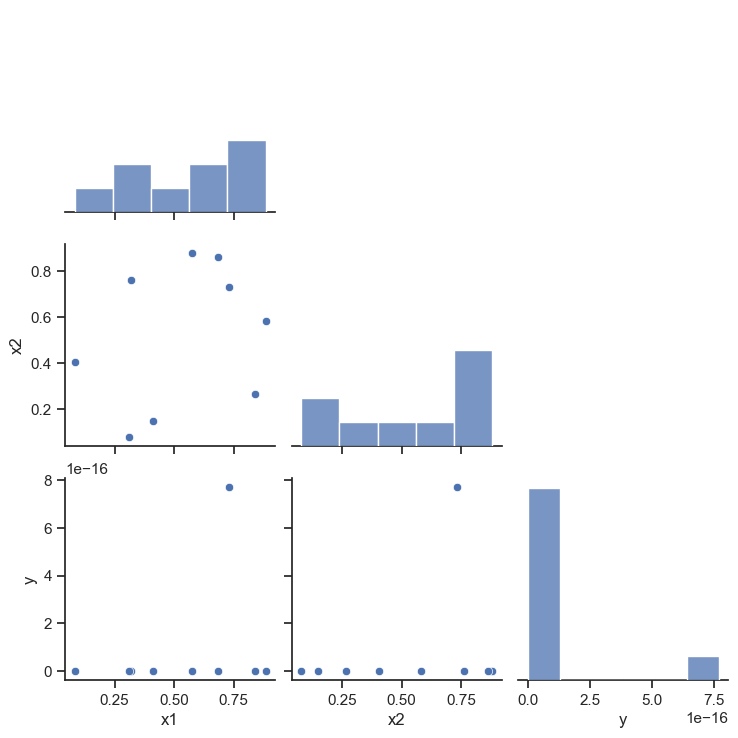

In [ ]:
sns.pairplot(df.drop(index=4), corner=True, diag_kind="hist")

## Visualisation: x1 vs x2 (excluding datapoint 4)

Since we are in a problem of contamination detection "where only proximity yields a non-zero reading", we can speculate that the x values refer to some kind of 2d mapping. We create a scatter plot of x1 vs x2, coloured by the output value y, excluding datapoint 4 to better visualise the relationships among the other datapoints. We use symlog bins to get useful colour gradients. We can see that all there is a greenish corner in the top right, which also includes our only meaningfully different positive value. It could indeicate that the these points pick up a minimal amount of the contamination source already. 


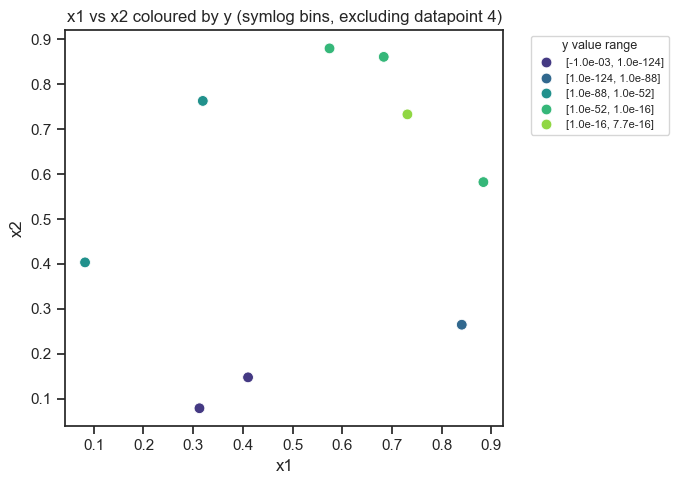

In [ ]:
plt.figure(figsize=(7, 5))
df_plot = df.drop(index=4).copy()
y_vals = df_plot["y"]
y_abs = np.abs(y_vals[y_vals != 0])
linthresh = y_abs.min() if len(y_abs) > 0 else 1e-50
vmin, vmax = y_vals.min(), y_vals.max()
y_pos = y_vals[y_vals > 0]
if len(y_pos) > 0:
    exp_min, exp_max = int(np.floor(np.log10(y_pos.min()))), int(np.ceil(np.log10(y_pos.max())))
    bins = [vmin]
    if y_pos.min() > 1e-12:
        bins.append(0)
    step = max(1, (exp_max - exp_min) // 3)
    bins.extend([10**e for e in range(exp_min, exp_max+1, step)])
    bins.append(vmax)
    bins = sorted(set([b for b in bins if vmin <= b <= vmax]))
else:
    bins = [vmin, 0, vmax]
df_plot["y_group"] = pd.cut(df_plot["y"], bins=bins, include_lowest=True, duplicates="drop")
label_map = {cat: f"[{cat.left:.1e}, {cat.right:.1e}]" for cat in df_plot["y_group"].cat.categories}
df_plot["y_label"] = df_plot["y_group"].map(label_map)
scatter = sns.scatterplot(data=df_plot, x="x1", y="x2", hue="y_label", palette="viridis", s=60, legend="auto")
plt.title("x1 vs x2 coloured by y (symlog bins, excluding datapoint 4)")
plt.legend(title="y value range", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()


## Analysis and recommendation

Our next steps could be to do some formal clustering analysis to confirm that the top right corner is currently the most interesting to analyse. We could also train a Bayesian optimisation to find the most promising point. However, we are in 2D space, and there is some visual rationale coming from the chart. The most promising option is to explore in that corner on the unity diagonal (given that we have three datapoints suggesting the signal fades above and underneath this diagonal). We decide to move inwards rather into the corner as the centre of the chart is largely unexplored at this stage. We pick the datapoint with coordinates (0.6,0.6) 